In [107]:
import os
os.chdir('/workspaces/energy-prediction/')  # Change le répertoire vers la racine
print(os.getcwd())  # Vérif

/workspaces/energy-prediction


In [108]:
# Import des bibliothèques
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#### Charger les données nettoyées

In [109]:
conso = pd.read_csv('./data/prepared/df_daily_conso.csv')
meteo = pd.read_csv('./data/prepared/meteo_clean.csv')
print(conso.columns)
print(meteo.columns)


Index(['Date', 'ConsommationGazTotale', 'ConsommationElectricite',
       'ConsommationTotale', 'month', 'day_of_week', 'is_weekend'],
      dtype='object')
Index(['date', 'temperature', 'humidity', 'pressure_sea_level',
       'wind_direction', 'wind_speed', 'min_soil_temp', 'latitude',
       'longitude', 'altitude', 'city_name', 'city_code', 'epci_name',
       'epci_code', 'department_name', 'department_code', 'region_name',
       'region_code', 'month_of_year'],
      dtype='object')


In [110]:
print(conso.head())
print(meteo.head())

         Date  ConsommationGazTotale  ConsommationElectricite  \
0  2012-01-01              1446815.0                  1237536   
1  2012-01-02              1791945.0                  1453549   
2  2012-01-03              2005753.0                  1625894   
3  2012-01-04              1997598.0                  1632020   
4  2012-01-05              2038430.0                  1660291   

   ConsommationTotale  month  day_of_week  is_weekend  
0           2684351.0      1            6           1  
1           3245494.0      1            0           0  
2           3631647.0      1            1           0  
3           3629618.0      1            2           0  
4           3698721.0      1            3           0  
                        date  temperature  humidity  pressure_sea_level  \
0  2010-01-01 00:00:00+00:00       280.45      87.0             99430.0   
1  2010-01-01 03:00:00+00:00       280.65      72.0             99460.0   
2  2010-01-01 06:00:00+00:00       280.55      6

##### conversion des dates

In [111]:
# Conversion des colonnes en format datetime
conso['Date'] = pd.to_datetime(conso['Date'])  # Pas besoin de dayfirst ici vu le format ISO
meteo['date'] = pd.to_datetime(meteo['date']).dt.date  # On garde uniquement la partie "date" (sans l'heure)
conso['Date'] = conso['Date'].dt.date  # Idem, pour faciliter la jointure


##### Fusion des fichiers sur la date

In [112]:
# Fusion des données sur la date (sans l'heure)
merged_data = pd.merge(conso, meteo, left_on='Date', right_on='date', how='inner')

# Suppression de la colonne redondante
merged_data.drop(columns=['date'], inplace=True)


##### Verification de la fusion

In [113]:
print(conso['Date'].head())
print(meteo['date'].head())  # Devrait être au format date sans heure
print(merged_data.head())    # Pour vérifier la jointure


0    2012-01-01
1    2012-01-02
2    2012-01-03
3    2012-01-04
4    2012-01-05
Name: Date, dtype: object
0    2010-01-01
1    2010-01-01
2    2010-01-01
3    2010-01-01
4    2010-01-01
Name: date, dtype: object
         Date  ConsommationGazTotale  ConsommationElectricite  \
0  2012-01-01              1446815.0                  1237536   
1  2012-01-01              1446815.0                  1237536   
2  2012-01-01              1446815.0                  1237536   
3  2012-01-01              1446815.0                  1237536   
4  2012-01-01              1446815.0                  1237536   

   ConsommationTotale  month  day_of_week  is_weekend  temperature  humidity  \
0           2684351.0      1            6           1       284.85      90.0   
1           2684351.0      1            6           1       284.75      90.0   
2           2684351.0      1            6           1       284.65      93.0   
3           2684351.0      1            6           1       284.95      94.0 

#### CORRELATION

In [114]:
print(merged_data.dtypes)

Date                        object
ConsommationGazTotale      float64
ConsommationElectricite      int64
ConsommationTotale         float64
month                        int64
day_of_week                  int64
is_weekend                   int64
temperature                float64
humidity                   float64
pressure_sea_level         float64
wind_direction             float64
wind_speed                 float64
min_soil_temp              float64
latitude                   float64
longitude                  float64
altitude                     int64
city_name                   object
city_code                   object
epci_name                   object
epci_code                  float64
department_name             object
department_code             object
region_name                 object
region_code                  int64
month_of_year                int64
dtype: object


##  Agréger les données à la journée

In [115]:
merged_data['Date'] = pd.to_datetime(merged_data['Date'])

sum_cols = ['ConsommationGazTotale', 'ConsommationElectricite', 'ConsommationTotale']

mean_cols = ['temperature', 'humidity', 'pressure_sea_level',
             'wind_direction', 'wind_speed', 'min_soil_temp']

df_daily = merged_data.groupby('Date')[sum_cols + mean_cols].agg({
    **{col: 'sum' for col in sum_cols},
    **{col: 'mean' for col in mean_cols}
}).reset_index()


### IMPORTS DES LIBS DU MODELE

In [116]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd

In [117]:
df_model = df_daily.copy()


### Création des variables temporelles

In [118]:
df_model['month'] = df_model['Date'].dt.month
df_model['day_of_week'] = df_model['Date'].dt.dayofweek
df_model['is_weekend'] = df_model['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)


### FEATURE & TARGET

In [119]:
target = 'ConsommationTotale'
features = [col for col in df_model.columns if col not in ['Date', target]]

X = df_model[features]
y = df_model[target]


### STANDARDISATION

In [120]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


### SPLIT TRAIN/TEST

In [121]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)


###  Ridge Regression

In [122]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

Ridge()

### Évaluation

In [123]:
y_pred = ridge.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print(f"📈 RMSE: {rmse:.2f}")
print(f"📉 MAE : {mae:.2f}")


📈 RMSE: 5316.66
📉 MAE : 3806.08


In [124]:
df_resultats["Erreur absolue"] = abs(df_resultats["Réel"] - df_resultats["Prédit"])
df_resultats["Erreur (%)"] = df_resultats["Erreur absolue"] / df_resultats["Réel"] * 100
print(df_resultats.head(10))


         Réel        Prédit  Erreur absolue  Erreur (%)
0  29161504.0  2.916181e+07      304.907521    0.001046
1  23968344.0  2.396183e+07     6514.114856    0.027178
2  13153544.0  1.314783e+07     5716.357102    0.043459
3  20989688.0  2.098620e+07     3487.170850    0.016614
4  30758184.0  3.075464e+07     3544.119237    0.011523
5  24661232.0  2.466209e+07      854.456318    0.003465
6  23800296.0  2.380364e+07     3342.405496    0.014044
7  25131544.0  2.513296e+07     1417.610318    0.005641
8  12646592.0  1.264740e+07      803.395981    0.006353
9  23606088.0  2.360923e+07     3144.775202    0.013322


### Importance des variables

In [125]:
coeffs = pd.Series(ridge.coef_, index=features)
coeffs_abs = coeffs.abs().sort_values(ascending=False)

print("🔍 Top variables influentes :")
print(coeffs_abs)


🔍 Top variables influentes :
ConsommationGazTotale      5.282276e+06
ConsommationElectricite    2.098068e+06
temperature                1.058043e+04
is_weekend                 1.492507e+03
humidity                   1.318173e+03
month                      1.207386e+03
min_soil_temp              1.160112e+03
wind_direction             8.486081e+02
day_of_week                2.349118e+02
pressure_sea_level         1.178162e+02
wind_speed                 7.337188e+01
dtype: float64


### Visualisation

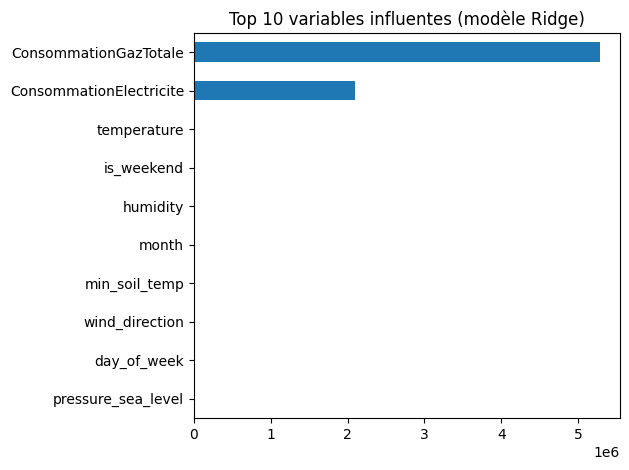

In [126]:
import matplotlib.pyplot as plt

coeffs_abs.head(10).plot(kind='barh')
plt.title("Top 10 variables influentes (modèle Ridge)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


In [127]:
# Comparaison y_test vs y_pred
df_resultats = pd.DataFrame({
    'Réel': y_test.values,
    'Prédit': y_pred
})
print(df_resultats.head(10))


         Réel        Prédit
0  29161504.0  2.916181e+07
1  23968344.0  2.396183e+07
2  13153544.0  1.314783e+07
3  20989688.0  2.098620e+07
4  30758184.0  3.075464e+07
5  24661232.0  2.466209e+07
6  23800296.0  2.380364e+07
7  25131544.0  2.513296e+07
8  12646592.0  1.264740e+07
9  23606088.0  2.360923e+07


In [128]:
def predict_conso_for_date(date_str, df_model, model, scaler):
    """
    Prédit la consommation totale pour une date donnée à partir des données existantes dans df_model.

    Params :
        - date_str : string 'YYYY-MM-DD'
        - df_model : DataFrame contenant la colonne 'Date' + toutes les features
        - model : modèle Ridge déjà entraîné
        - scaler : StandardScaler déjà entraîné

    Retour :
        - Affiche la prédiction ou un message d'erreur
    """
    import pandas as pd

    date = pd.to_datetime(date_str)

    # Chercher la ligne correspondante
    row = df_model[df_model['Date'] == date]

    if row.empty:
        print(f"❌ Aucune donnée disponible pour la date : {date_str}")
        return None

    # Définir les colonnes features
    target = 'ConsommationTotale'
    features = [col for col in df_model.columns if col not in ['Date', target]]

    X_input = row[features]

    # Standardisation
    X_scaled = scaler.transform(X_input)

    # Prédiction
    prediction = model.predict(X_scaled)[0]

    print(f"🔮 Consommation prédite pour le {date_str} : {prediction:.0f} MWh")
    return prediction


In [129]:
# 💡 Remplace ici par la date que tu veux tester
ma_date = "2025-04-30"


In [130]:
# Lancer la prédiction avec ta date
predict_conso_for_date(ma_date, df_model, ridge, scaler)


❌ Aucune donnée disponible pour la date : 2025-04-30
